In [1]:
import random

import numpy as np
import pandas as pd
from multisynth import multisynth

# 1. Use multisynth to estimate a penalized synthetic control model measuring the effects of the staggered entry of Walmart Supercenters on local labor markets (Wiltshire 2023)

In this notebook I re-create estimates from Wiltshire (2023), who uses a staggered treatment penalized synthetic control setup to estimate the local labor market impacts of Walmart Supercenter openings. 

Wiltshire's data panel consists of county-level labor data on counties Walmart opened supercenters in from 1990-2005. In addition, the panel includes data on counties that Wal-Mart tried but failed to open supercenters in. We will use these control counties to construct synthetic versions of each treated county, then stack the estimates and perform inference. 

In [ ]:
synth_walmart = pd.read_stata("data/allsynth_walmart.dta", convert_dates=False)

In [3]:
pd.concat([synth_walmart.head(3), synth_walmart.tail(3)])

,cty_fips,year,pe_salary_n44,pe_salary_n10,emps_n44,emps_n10,pop_t,super_year,unr,lfp,emr,czone,emps_shr_n44,supercenter,prop_white,pop90
0,1001,1990,21313.800781,30677.488281,1184.333374,7870.833496,34353,1996.0,0.065246,0.649237,0.606877,11101.0,0.150471,1.0,0.795185,34353.0
1,1001,1991,20566.085938,30883.527344,1320.916748,8077.500000,35010,1996.0,0.067638,0.637902,0.594756,11101.0,0.163530,1.0,0.798372,34353.0
2,1001,1992,20853.433594,30596.441406,1405.833252,8397.083008,35985,1996.0,0.065063,0.645066,0.603096,11101.0,0.167419,1.0,0.800528,34353.0
9677,56037,2003,25858.203125,48054.632812,2260.500000,19453.083984,37450,2000.0,0.040029,0.712191,0.683683,36404.0,0.116203,1.0,0.957196,38792.0
9678,56037,2004,26705.759766,48523.820312,2345.500000,20439.250000,38026,2000.0,0.032738,0.717975,0.694471,36404.0,0.114755,1.0,0.956688,38792.0
9679,56037,2005,28030.039062,51025.187500,2419.083252,21849.750000,38739,2000.0,0.028955,0.735648,0.714347,36404.0,0.110714,1.0,0.955394,38792.0


## Formatting calls to multisynth.fit
Stacked synthetic control models are fit using the method multisynth.fit_multisynth. The method takes the following arguments:
1. **data** a pandas dataframe in the form above.
2. **variable_specs** A dictionary describing which variables in the panel should be used  for synthetic control matching and how the variables should be mutated (e.g. averaged over a set of years, normalized, including for specific years)  
3. **treatment_var** (str) Name of column describing when an entity receives treatment (e.g. *super_year*)
4. **unit_var** (str) Name of column containing unit identifiers  (e.g. *cty_fips*)
5. **time_var** (str) Name of column containing time of observations in panel (e.g. *year*)
6. **outcome_var** (str) Name of column containing outcome variable (e.g. *emps_n10*, *pe_salary_n10*)
7. **penalized** (bool) If true, use an estimator that penalizes distances between synthetic covariates and treated covariates (based on Abadie & L'hour 2021; Wiltshire (2023)) 
8. **normalize_outcomes** (bool) If true, report outcomes in %  change from value in the period before treatment
9. **verbose** (bool) If true, for each treated unit, print the following
    1. A dataframe comparing treated covariates to synthetic covariates
    2. The lambda value that optimizes 

## 1.1 Specify stacked synthetic control setup and build **variable_specs**

Following Wiltshire (2023), we match counties to synthetic donors on the following variables:

    1. All industry employment in years 1990, 1991, 1992, and 1993
    2. All industry employment averaged over 1990-1994
    3. Retail industry employment averaged over 1990-1994
    4. All industry average wages averaged over 1990-1994
    5. Share of labor in retail industry  averaged over 1990-1994
    6. Population  averaged over 1990-1994
    7. Unemployment rate
    8. Employment rate
    9. White share of population

We normalize the first six variables for each county to their value in the year before treatment

In [4]:
variable_specs_walmart = [
    {
        "var": "emps_n10",
        "specification": {
            "aggregate_option": "individual",
            "normalize": True,
            "periods": [1990, 1991, 1992, 1993]
        }
    },
    {
        "var": "emps_n10",
        "specification": {
            "aggregate_option": "avg",
            "normalize": True,
            "periods": range(1990,1995)
        }
    },
    {
        "var": "emps_n44",
        "specification": {
            "aggregate_option": "avg",
            "normalize": True,
            "periods": range(1990,1995)
        }
    },
    {
        "var": "pe_salary_n10",
        "specification": {
            "aggregate_option": "avg",
            "normalize": True,
            "periods": range(1990,1995)
        }
    },
    {
        "var": "pe_salary_n44",
        "specification": {
            "aggregate_option": "avg",
            "normalize": True,
            "periods": range(1990,1995)
        }
    },
    {
        "var": "emps_shr_n44",
        "specification": {
            "aggregate_option": "avg",
            "normalize": True,
            "periods": range(1990,1995)
        }
    },
    {
        "var": "pop_t",
        "specification": {
            "aggregate_option": "avg",
            "normalize": True,
            "periods": range(1990,1995)
        }
    },
    {
        "var": "unr",
        "specification": {
            "aggregate_option": "avg",
            "periods": range(1990,1995)
        }
    },
    {
        "var": "emr",
        "specification": {
            "aggregate_option": "avg",
            "periods": range(1990,1995)
        }
    },
    {
        "var": "lfp",
        "specification": {
            "aggregate_option": "avg",
            "periods": range(1990,1995)
        }
    },
    {
        "var": "prop_white",
        "specification": {
            "aggregate_option": "avg",
            "periods": range(1990,1995)
        }
    }
]

## 1.2 Fit the synthetic control model

Below I estimate the effect of Walmart supercenter entry on total county employment. To speed up estimates, I limit treated counties to the state of Indiana (fips = 18) but use control counties from across the country. 

In [5]:
m = multisynth.MultiSynth()

synth_walmart = synth_walmart[(synth_walmart["supercenter"] == 0) | (np.floor(synth_walmart["cty_fips"]/1000) == 18)]
weights = m.fit_multisynth(data=synth_walmart, 
                           variable_specs=variable_specs_walmart,
                           treatment_var="super_year",
                           unit_var="cty_fips",
                           time_var="year",
                           outcome_var="emps_n10",
                           penalized=True,
                           normalize_outcomes=True,
                           verbose=False,
                        )

Estimating synthetic control for unit cty_fips=18179 (1/26)
Estimating synthetic control for unit cty_fips=18053 (2/26)
Estimating synthetic control for unit cty_fips=18181 (3/26)
Estimating synthetic control for unit cty_fips=18055 (4/26)
Estimating synthetic control for unit cty_fips=18183 (5/26)
Estimating synthetic control for unit cty_fips=18057 (6/26)
Estimating synthetic control for unit cty_fips=18167 (7/26)
Estimating synthetic control for unit cty_fips=18063 (8/26)
Estimating synthetic control for unit cty_fips=18067 (9/26)
Estimating synthetic control for unit cty_fips=18071 (10/26)
Estimating synthetic control for unit cty_fips=18077 (11/26)
Estimating synthetic control for unit cty_fips=18081 (12/26)
Estimating synthetic control for unit cty_fips=18083 (13/26)
Estimating synthetic control for unit cty_fips=18097 (14/26)
Estimating synthetic control for unit cty_fips=18117 (15/26)
Estimating synthetic control for unit cty_fips=18127 (16/26)
Estimating synthetic control for 

## 1.2.1 Inspect covariate balance between treated and synthetic units

Below we preview how well synthetic control units mimic treated units

In [6]:
random_treated_unit = random.choice(weights.index.unique())
m.get_synthetic_covariate_comparisons(random_treated_unit)

cty_fips,18031,synth_18031
var,,
emps_n10_1990,0.693214,0.686799
emps_n10_1991,0.701913,0.715298
emps_n10_1992,0.755094,0.761536
emps_n10_1993,0.820709,0.832106
emps_n10_avg_1990_1994,0.771467,0.774290
emps_n44_avg_1990_1994,0.890606,0.892367
emps_shr_n44_avg_1990_1994,1.159004,1.160136
emr_avg_1990_1994,0.689953,0.661017
lfp_avg_1990_1994,0.718353,0.701567


## 1.2.2 View synthetic control results

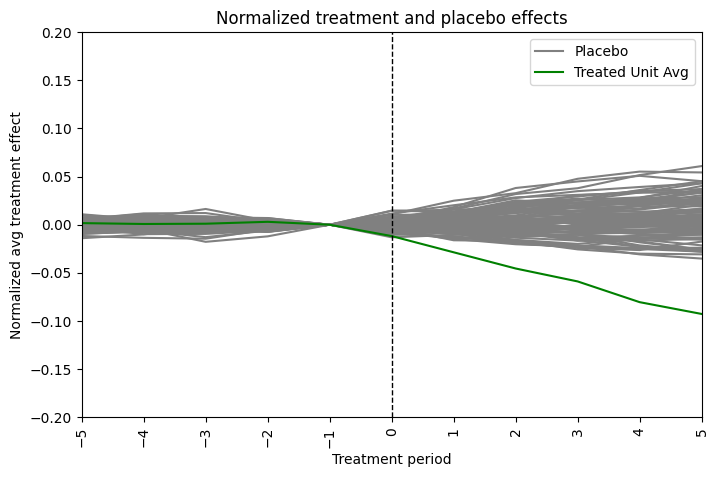

In [7]:
m.plot_treatment_and_placebos(num_placebos=100, 
                              pre_treat_periods=5, 
                              post_treat_periods=5, 
                              ylim=(-0.2, 0.2))

In [8]:
# View treatment effects averaged over 5 periods post-treatment 
m.get_ate(post_treat_periods = 5)

-0.06359965368053268

In [9]:
m.get_p_value()

0.219

# 2. Estimate a penalized synthetic control model for a classical single treatment case (Abadie, Diamond, and Hainmueller 2010)

Below I re-create estimates from Abadie, Diamond, and Hainmueller 2010), who use a synthetic control setup to estimate the effect of California's Proposition 99, a tobacco control program, on smoking rates in the state. I use a penalized estimator. 


In [2]:
synth_smoking = pd.read_csv("data/synth_smoking.csv")
synth_smoking["treated"] = synth_smoking.apply(lambda row: 1989 if row["state"]== "California" else None, axis=1)
pd.concat([synth_smoking.head(3), synth_smoking.tail(3)])

,state,year,cigsale,lnincome,beer,age15to24,retprice,treated
0,Rhode Island,1970,123.900000,NaN,NaN,0.183158,39.299999,NaN
1,Tennessee,1970,99.800003,NaN,NaN,0.178044,39.900002,NaN
2,Indiana,1970,134.600010,NaN,NaN,0.176516,30.600000,NaN
1206,Vermont,2000,88.900002,NaN,NaN,NaN,301.100010,NaN
1207,Ohio,2000,99.900002,NaN,NaN,NaN,265.399990,NaN
1208,Rhode Island,2000,83.099998,NaN,NaN,NaN,322.899990,NaN


## 2.1 Specify stacked synthetic control setup and build **variable_specs**

In [3]:
smoking_variable_specs = [
    {
        "var": "beer",
        "specification": {
            "aggregate_option": "avg",
            "periods": range(1984,1988)
        }
    },
    {
        "var": "lnincome",
        "specification": {
            "aggregate_option": "avg",
        }
    },
    {
        "var": "retprice",
        "specification": {
            "aggregate_option": "avg",
        }
    },
    {
        "var": "age15to24",
        "specification": {
            "aggregate_option": "avg"
        }
    },
    {
        "var": "cigsale",
        "specification": {
            "aggregate_option": "individual",
            "periods": [1988, 1980, 1975]
        }
    }
] 

## 2.2 Fit the synthetic control model

In [4]:
m = multisynth.MultiSynth()
weights = m.fit_multisynth(data=synth_smoking, 
                           variable_specs=smoking_variable_specs,
                           treatment_var="treated",
                           unit_var="state",
                           time_var="year",
                           outcome_var="cigsale",
                           normalize_outcomes=True,
                           penalized=True)

Estimating synthetic control for unit state=California (1/1)


### 2.2.1 Inspect synthetic control composition

In [5]:
m.get_unit_weights("California")

,unit,weight
6,Nevada,0.051070
9,Idaho,0.573514
10,Montana,0.252631
33,Connecticut,0.122784


### 2.2.2 Inspect covariate balance between treated and synthetic units

In [6]:
m.get_synthetic_covariate_comparisons("California")

state,California,synth_California
var,,
age15to24_avg_1970_1988,0.178662,0.165384
beer_avg_1984_1987,24.450000,24.366983
cigsale_1975,127.100000,125.975234
cigsale_1980,120.200000,120.453583
cigsale_1988,90.099998,90.580795
lnincome_avg_1970_1988,10.031759,9.787598
retprice_avg_1970_1988,66.636843,64.770564


## 2.3.3 View synthetic control results

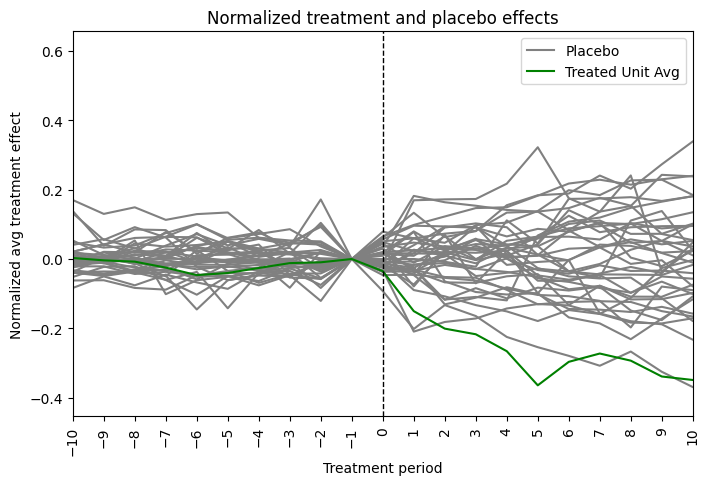

In [7]:
m.plot_treatment_and_placebos(pre_treat_periods=10, 
                              post_treat_periods=10)

In [8]:
# View treatment effects averaged over 5 periods post-treatment 
m.get_ate(post_treat_periods = 5)

-0.24664250191747422

In [9]:
m.get_p_value()

0.024